In [57]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import seaborn as sns
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from sklearn.svm import LinearSVC
from imblearn.over_sampling import ADASYN

In [21]:
df=pd.read_csv("../data/classifications/diabetes.csv")

In [22]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [23]:
df["Pregnancies"].unique()

array([ 6,  1,  8,  0,  5,  3, 10,  2,  4,  7,  9, 11, 13, 15, 17, 12, 14])

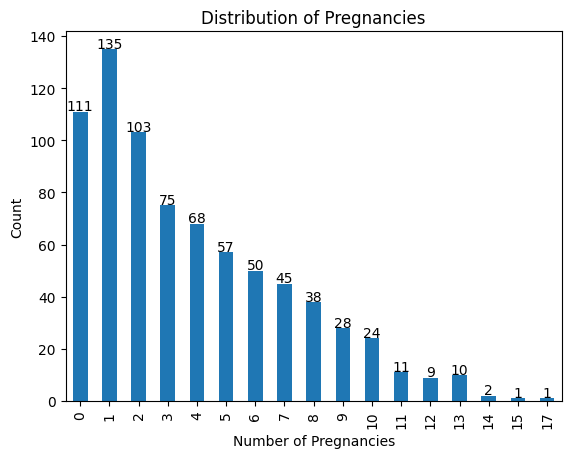

In [24]:
counts = df['Pregnancies'].value_counts().sort_index()
ax = counts.plot(kind='bar')

plt.xlabel('Number of Pregnancies')
plt.ylabel('Count')
plt.title('Distribution of Pregnancies')

# Add labels on top of each bar
for i, v in enumerate(counts):
    ax.text(i, v + 0.5, str(v), ha='center')

plt.show()

In [25]:
df.describe(include='all')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [26]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [27]:
feature_cols = ['Pregnancies', 'Insulin', 'BMI', 'Age','Glucose','BloodPressure','DiabetesPedigreeFunction']
X = df[feature_cols] 
y = df["Outcome"] 

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=16)

In [10]:
y.value_counts(normalize=True) * 100

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

<h1>I see class imbalance</h1>

In [23]:
# instantiate the model (using the default parameters)
logreg = LogisticRegression(random_state=16)

# fit the model with data
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)

/Users/razzaqismath/Documents/python/tools4hack/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [39]:
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix
tn, fp, fn, tp = cnf_matrix.ravel()

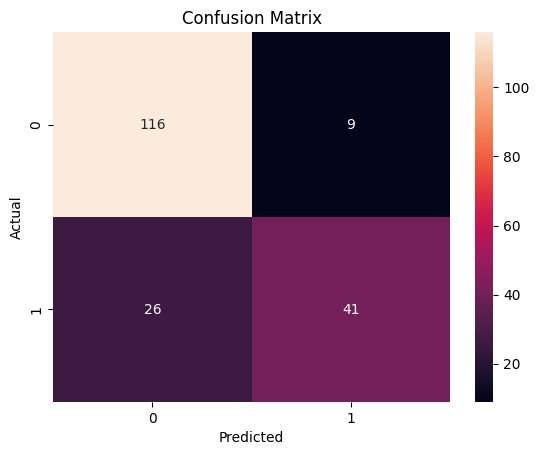

In [32]:
# Plot heatmap
plt.figure()
sns.heatmap(cnf_matrix, annot=True, fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

116 → True Negatives (correctly predicted 0)
9 → False Positives (predicted 1 but actually 0)
26 → False Negatives (predicted 0 but actually 1)
41 → True Positives (correctly predicted 1)

In [36]:
target_names = ['without diabetes', 'with diabetes']
print(metrics.classification_report(y_test, y_pred, target_names=target_names))

                  precision    recall  f1-score   support

without diabetes       0.82      0.93      0.87       125
   with diabetes       0.82      0.61      0.70        67

        accuracy                           0.82       192
       macro avg       0.82      0.77      0.78       192
    weighted avg       0.82      0.82      0.81       192



In [40]:
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall:", metrics.recall_score(y_test, y_pred))
print("F1 Score:", metrics.f1_score(y_test, y_pred))
specificity = tn / (tn + fp)

print("Specificity:", specificity)

Accuracy: 0.8177083333333334
Precision: 0.82
Recall: 0.6119402985074627
F1 Score: 0.7008547008547008
Specificity: 0.928


Specificity (True Negative Rate)
false positive rate, or 1 – specificity


✅ Accuracy (~82%)
Overall, your model is correct most of the time
Sounds good, but can be misleading if classes are imbalanced

✅ Precision (0.82 — good)
When your model predicts positive, it's correct 82% of the time
👉 Low false positives (good)

⚠️ Recall-Sensitivity (True Positive Rate) (0.61 — weak point)
Your model only catches ~61% of actual positives
👉 It misses ~39% of real positive cases
This is the biggest issue.

⚖️ F1 Score (0.70)
A balance between precision and recall
This reflects the drop caused by low recall

🚨 Practical interpretation (important)

If this is something like disease prediction (e.g., diabetes):

✅ You don’t wrongly alarm people too often (good precision)
❌ But you miss many actual cases (bad recall)

👉 In real-world scenarios, missing positives is usually worse than false alarms

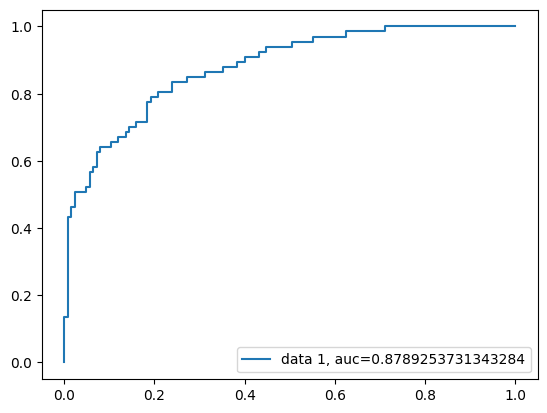

In [37]:
y_pred_proba = logreg.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()

⚠️ Important insight (connect to earlier results)

Earlier you had:

Recall ≈ 0.61 (low)
Specificity ≈ 0.93 (high)

👉 But ROC shows:

The model can achieve better recall — just not at the default threshold (0.5)

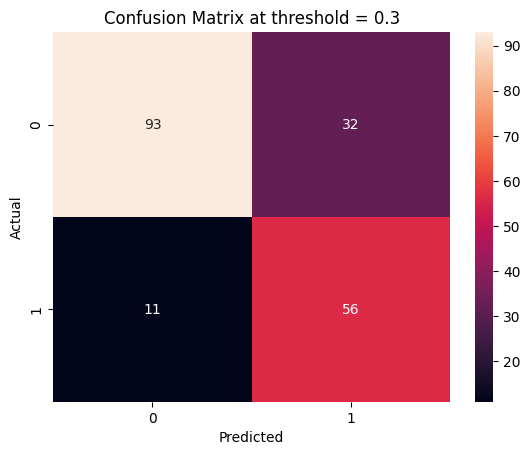

Accuracy: 0.7760416666666666
Precision: 0.6363636363636364
Recall: 0.835820895522388
F1 Score: 0.7225806451612903
Specificity: 0.744

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.74      0.81       125
           1       0.64      0.84      0.72        67

    accuracy                           0.78       192
   macro avg       0.77      0.79      0.77       192
weighted avg       0.80      0.78      0.78       192



In [46]:
# 1. Get probability for class 1
y_prob = logreg.predict_proba(X_test)[:, 1]

# 2. Choose a custom threshold
threshold = 0.3
y_pred_new = (y_prob >= threshold).astype(int)

# 3. Confusion matrix
cm = metrics.confusion_matrix(y_test, y_pred_new)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix at threshold = {threshold}')
plt.show()

# 4. Evaluation metrics
print("Accuracy:", metrics.accuracy_score(y_test, y_pred_new))
print("Precision:", metrics.precision_score(y_test, y_pred_new))
print("Recall:", metrics.recall_score(y_test, y_pred_new))
print("F1 Score:", metrics.f1_score(y_test, y_pred_new))

# Specificity
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
print("Specificity:", specificity)

print("\nClassification Report:")
print(metrics.classification_report(y_test, y_pred_new))

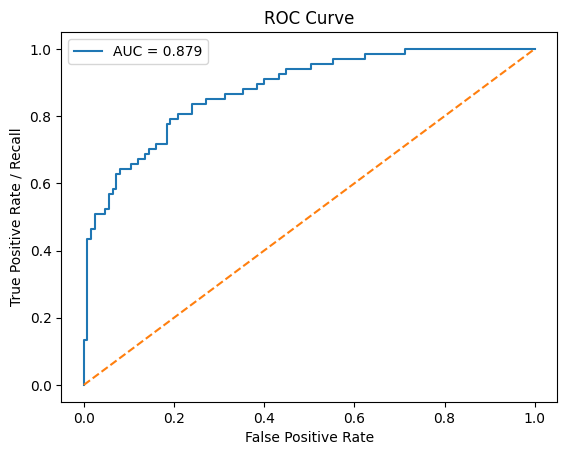

In [49]:
# ROC curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_prob)
roc_auc = metrics.auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate / Recall')
plt.title('ROC Curve')
plt.legend()
plt.show()

🧠 What this means in practice
Before (threshold = 0.5)
Model is strict
Needs high confidence to predict positive
👉 Fewer false positives
👉 BUT misses many real positives (low recall)

After (threshold = 0.3)
Model is more lenient
Easier to predict positive
👉 Catches more real positives (higher recall)
👉 But may increase false positives

In [54]:
for threshold in [0.5, 0.3]:
    y_pred_temp = (y_prob >= threshold).astype(int)
    cm = metrics.confusion_matrix(y_test, y_pred_temp)
    tn, fp, fn, tp = cm.ravel()

    print(f"\nThreshold: {threshold}")
    print(cm)
    print("Accuracy:", metrics.accuracy_score(y_test, y_pred_temp))
    print("Precision:", metrics.precision_score(y_test, y_pred_temp))
    print("Recall:", metrics.recall_score(y_test, y_pred_temp))
    print("F1 Score:", metrics.f1_score(y_test, y_pred_temp))
    print("Specificity:", tn / (tn + fp))


Threshold: 0.5
[[116   9]
 [ 26  41]]
Accuracy: 0.8177083333333334
Precision: 0.82
Recall: 0.6119402985074627
F1 Score: 0.7008547008547008
Specificity: 0.928

Threshold: 0.3
[[93 32]
 [11 56]]
Accuracy: 0.7760416666666666
Precision: 0.6363636363636364
Recall: 0.835820895522388
F1 Score: 0.7225806451612903
Specificity: 0.744


<h1>Dealing with Imbalance data</h1>

<h2>Strategy 1. Random Oversampling</h2>

In [16]:
# Function for plotting dataset 
def plot_data(X,y,ax,title):
    ax.scatter(X[:, 0], X[:, 1], c=y, alpha=0.5, s = 30, edgecolor=(0,0,0,0.5))
    ax.set_ylabel('Principle Component 1')
    ax.set_xlabel('Principle Component 2')
    if title is not None:
        ax.set_title(title)

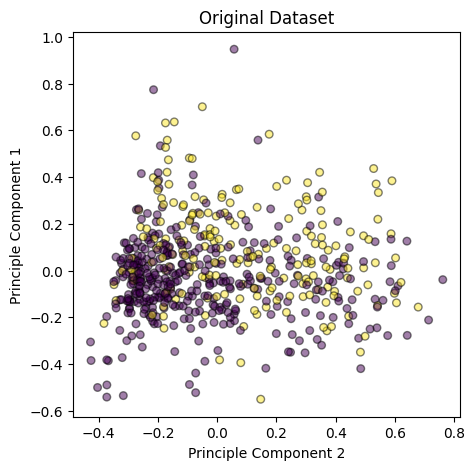

In [17]:
# Scale the dataset on both train and test sets.
# Note that we fit MinMaxScaler on X_train only, not on the entire dataset.
# This prevents data leakage from test set to train set.
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# Perform PCA Decomposition on both train and test sets
# Note that we fit PCA on X_train only, not on the entire dataset.
# This prevents data leakage from test set to train set.
pca = PCA(n_components=2)
pca.fit(X_train)
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)


# Plot dataset
fig,ax = plt.subplots(figsize=(5, 5))
plot_data(X_train_pca, y_train, ax, title='Original Dataset')

In [14]:
# Perform random oversampling
ros = RandomOverSampler(random_state=0)
X_train_ros, y_train_ros = ros.fit_resample(X_train_pca, y_train)

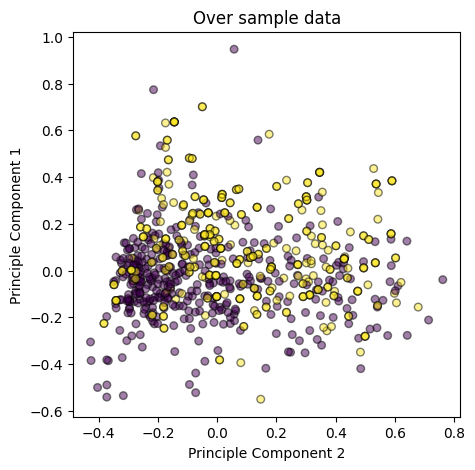

In [38]:
fig,ax = plt.subplots(figsize=(5, 5))
plot_data(X_train_ros, y_train_ros, ax, title='Over sample data')

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=16)

In [39]:
ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

In [40]:
y_train_resampled.value_counts(normalize=True) * 100

Outcome
1    50.0
0    50.0
Name: proportion, dtype: float64

In [41]:

# instantiate the model (using the default parameters)
logreg = LogisticRegression(random_state=16)

# fit the model with data
logreg.fit(X_train_resampled, y_train_resampled)

y_pred = logreg.predict(X_test)

In [42]:
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix
tn, fp, fn, tp = cnf_matrix.ravel()

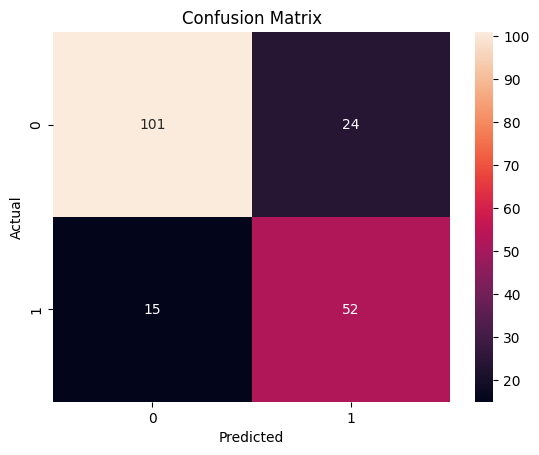

In [43]:
# Plot heatmap
plt.figure()
sns.heatmap(cnf_matrix, annot=True, fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [44]:
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall:", metrics.recall_score(y_test, y_pred))
print("F1 Score:", metrics.f1_score(y_test, y_pred))
specificity = tn / (tn + fp)

print("Specificity:", specificity)

Accuracy: 0.796875
Precision: 0.6842105263157895
Recall: 0.7761194029850746
F1 Score: 0.7272727272727273
Specificity: 0.808


<h2>Strategy 2. Random Undersampling</h2>

/Users/razzaqismath/Documents/python/tools4hack/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


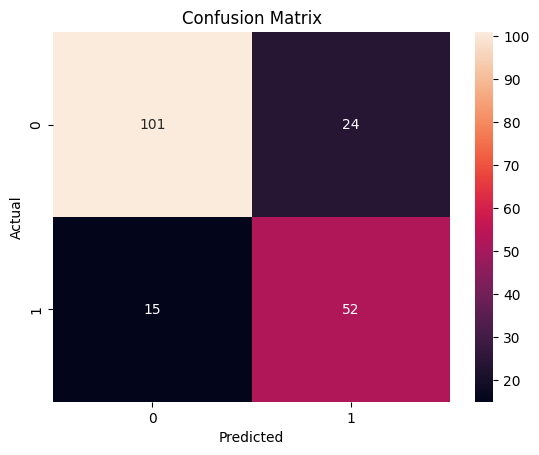

In [51]:
rus = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)
model = LogisticRegression()
model.fit(X_train_resampled, y_train_resampled)
y_pred = model.predict(X_test)

cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cnf_matrix.ravel()

plt.figure()
sns.heatmap(cnf_matrix, annot=True, fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()


In [52]:
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall:", metrics.recall_score(y_test, y_pred))
print("F1 Score:", metrics.f1_score(y_test, y_pred))
specificity = tn / (tn + fp)

print("Specificity:", specificity)

Accuracy: 0.796875
Precision: 0.6842105263157895
Recall: 0.7761194029850746
F1 Score: 0.7272727272727273
Specificity: 0.808


<h2>Strategy 3. Oversampling with SMOTE</h2>

Here’s how SMOTE works (simplified).

Randomly select some data points in the minority class.
For every selected point, identify its k nearest neighbour(s).
For every neighbor, add a new point somewhere between the data point and the neighbor.
Repeat steps 2 to 4 until sufficient synthetic data points are created.

Before SMOTE:
Outcome
0    375
1    201
Name: count, dtype: int64
After SMOTE:
Outcome
1    375
0    375
Name: count, dtype: int64


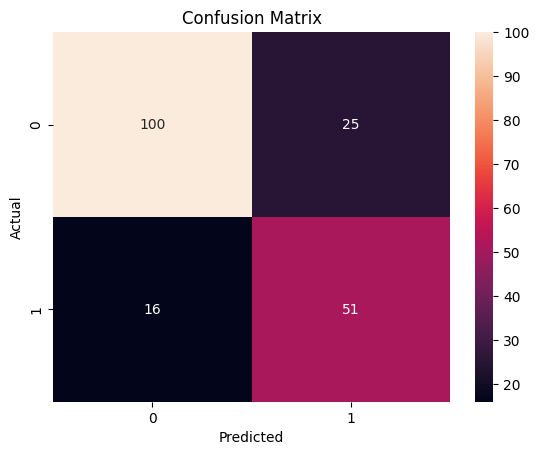

In [55]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("After SMOTE:")
print(y_train_smote.value_counts())

model = LogisticRegression(max_iter=1000)
model.fit(X_train_smote, y_train_smote)
y_pred = model.predict(X_test)

cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cnf_matrix.ravel()

plt.figure()
sns.heatmap(cnf_matrix, annot=True, fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [56]:
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall:", metrics.recall_score(y_test, y_pred))
print("F1 Score:", metrics.f1_score(y_test, y_pred))
specificity = tn / (tn + fp)

print("Specificity:", specificity)

Accuracy: 0.7864583333333334
Precision: 0.6710526315789473
Recall: 0.7611940298507462
F1 Score: 0.7132867132867133
Specificity: 0.8


<h2>Strategy 4. Oversampling with ADASYN</h2>

ADASYN (Adaptive Synthetic Sampling) is an oversampling technique similar to SMOTE, but with a key improvement:

It generates more synthetic data for harder-to-learn minority samples.

🧠 Core idea
Instead of treating all minority samples equally (like SMOTE does), ADASYN:
👉 Focuses on difficult regions where the model struggles
👉 Generates more synthetic points there

🔁 How it works (intuitively)
1. Find minority samples
Look at all points where y = 1 (minority class)

2. Measure difficulty
For each minority point:
Look at its neighbors
Count how many belong to the majority class
👉 If many neighbors are majority → this point is hard to learn

3. Assign importance
Easy points → fewer synthetic samples
Hard points → more synthetic samples

4. Generate synthetic data
Like SMOTE:
Interpolates between minority points
But more samples are created in difficult areas

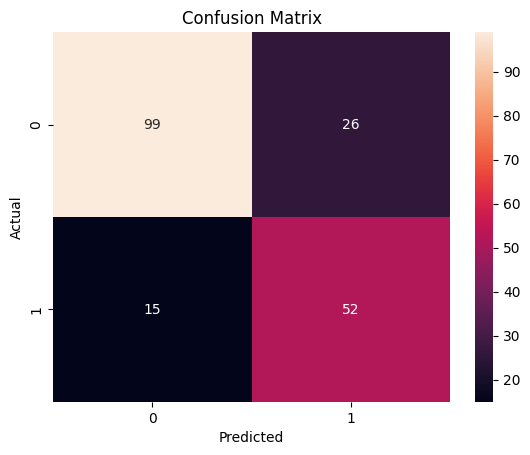

In [62]:
adasyn = ADASYN(random_state=42)
X_train_res, y_train_res = adasyn.fit_resample(X_train, y_train)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_res, y_train_res)
y_pred = model.predict(X_test)

cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cnf_matrix.ravel()

plt.figure()
sns.heatmap(cnf_matrix, annot=True, fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [60]:
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall:", metrics.recall_score(y_test, y_pred))
print("F1 Score:", metrics.f1_score(y_test, y_pred))
specificity = tn / (tn + fp)

print("Specificity:", specificity)

Accuracy: 0.7864583333333334
Precision: 0.6666666666666666
Recall: 0.7761194029850746
F1 Score: 0.7172413793103448
Specificity: 0.792


<h1 style="color:red">Scores have not improved</h1>

1. Features may not separate the classes well
If your input columns don’t contain enough signal, balancing the classes won’t help much.

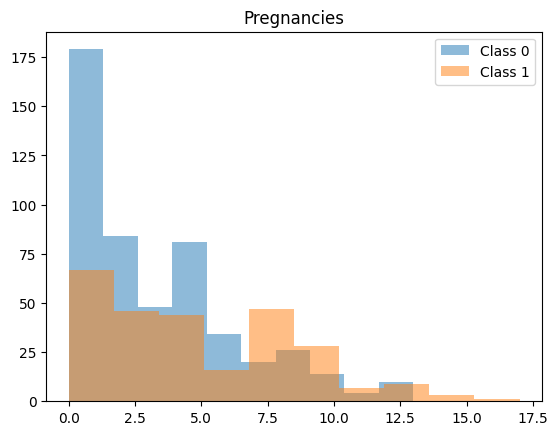

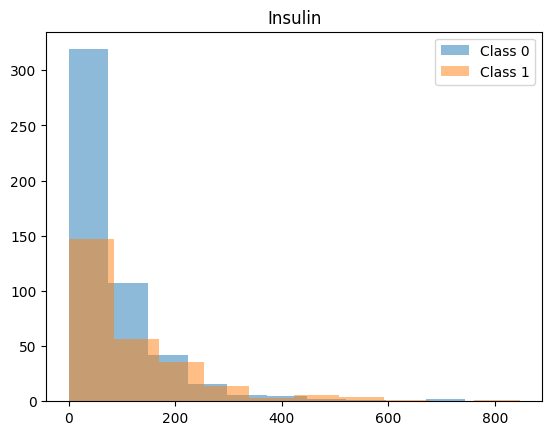

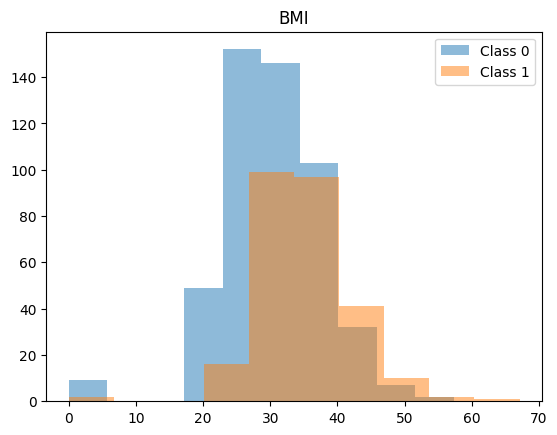

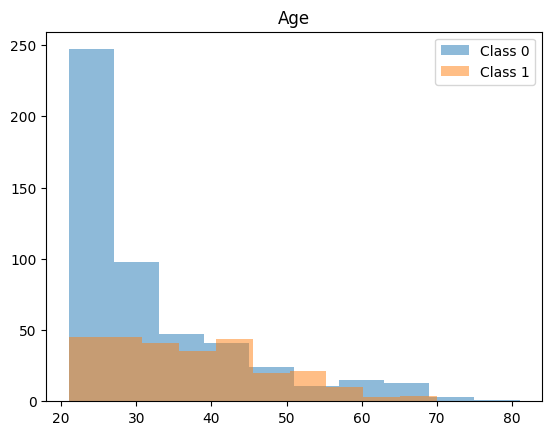

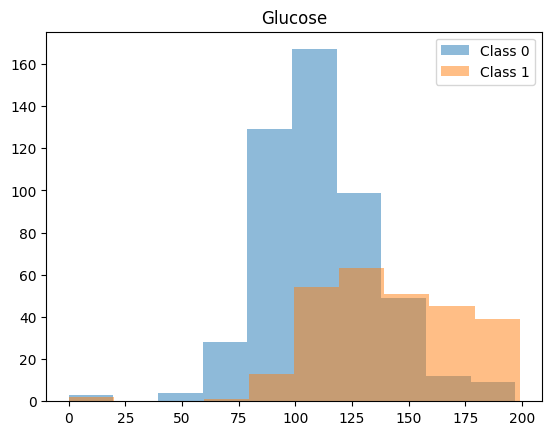

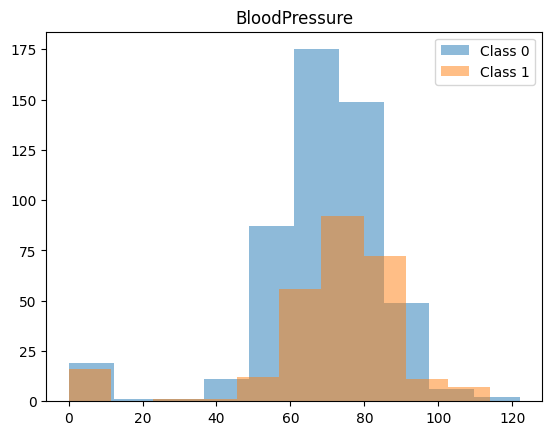

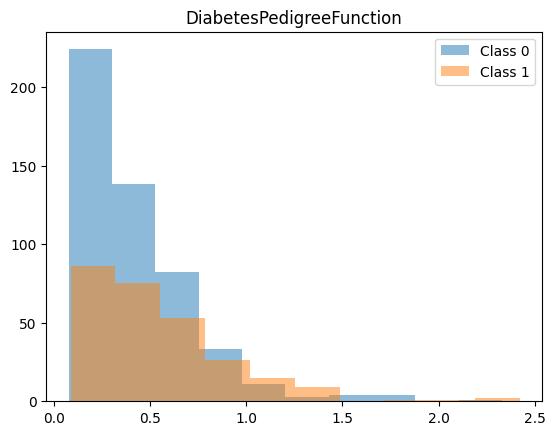

In [63]:
for col in X.columns:
    plt.figure()
    plt.hist(df[df["Outcome"] == 0][col], alpha=0.5, label="Class 0")
    plt.hist(df[df["Outcome"] == 1][col], alpha=0.5, label="Class 1")
    plt.title(col)
    plt.legend()
    plt.show()

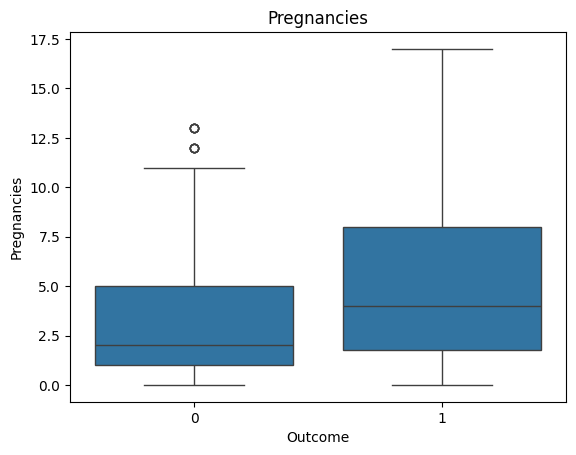

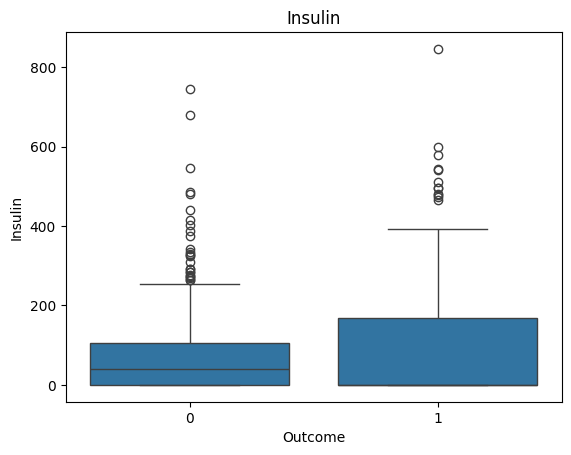

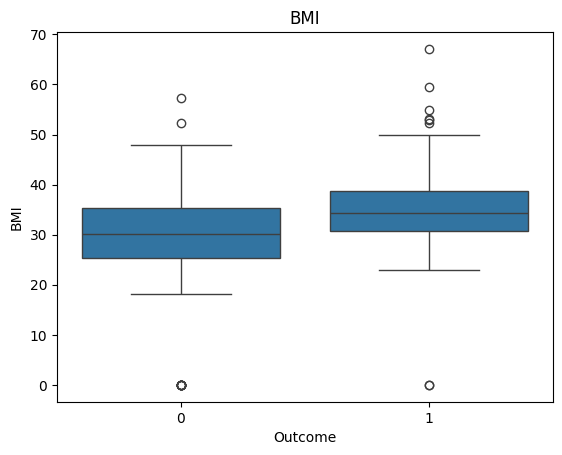

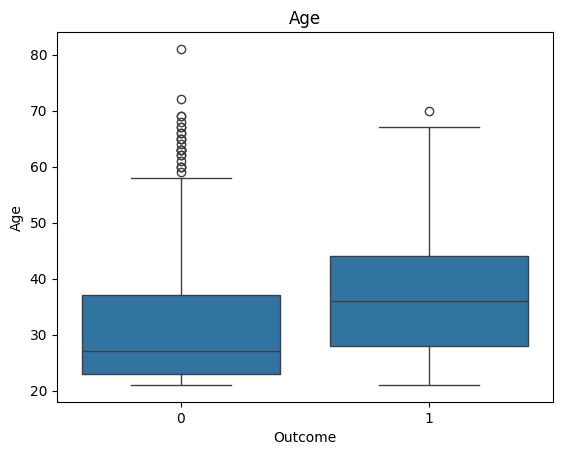

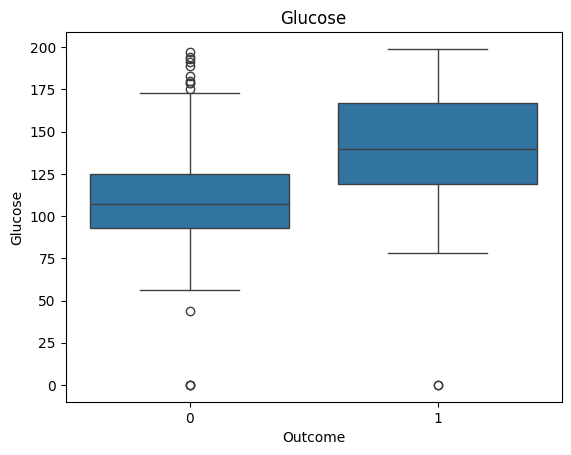

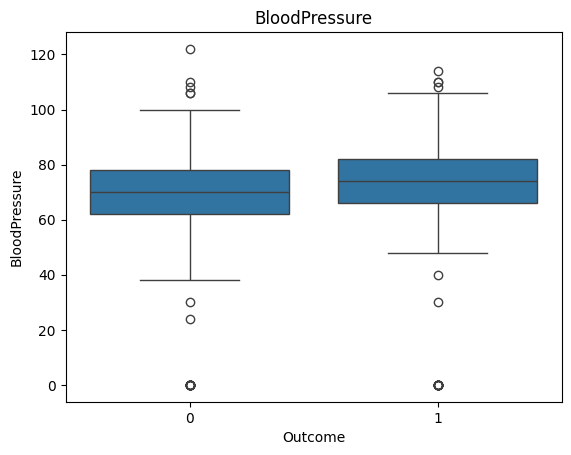

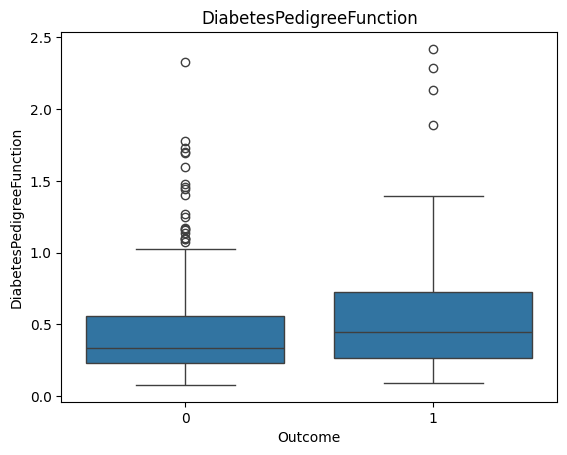

In [64]:
for col in X.columns:
    sns.boxplot(x="Outcome", y=col, data=df)
    plt.title(col)
    plt.show()